# Gaussian direct and indirect PMP comparison

Rows show loss functions or assumed models; columns show assumed models or diagnostic scores. All panels use the same model order, facet strips, axes, and legend placement as the M1–M4 summary notebook.


In [9]:
import hashlib
import json
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = next(
    (parent for parent in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
     if (parent / "benchmark/examples/gaussian/config.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from inside the benchmark2 repository.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.gaussian.config import NETWORK_DIR
RESULTS_DIR = PROJECT_ROOT / "benchmark/examples/gaussian/results/direct"
LOSS_FUNCTIONS = ("cross_entropy", "exponential", "logistic")
LOSS_LABELS = {
    "cross_entropy": "Cross-entropy",
    "exponential": "Exponential",
    "logistic": "Logistic",
}
FIGURE_DIR = RESULTS_DIR / "direct_loss_comparison" / "figures"

MODELS = ("m1", "m2", "m3", "m4")
ALL_SOURCES = tuple(f"m{i}" for i in range(1, 13))
SOURCES_TO_PLOT = ALL_SOURCES  # Example subset: ("m5", "m8")
FIGURE_SUFFIX = "all"
SOURCE_LABEL = "M1–M12"  # Update the label and suffix when selecting a subset.
def file_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


# Plot the saved direct results after checking their checkpoint and file hashes.
diagnostic_frames_by_loss = {}
for loss in LOSS_FUNCTIONS:
    checkpoint = NETWORK_DIR / f"direct_{loss}.keras"
    output = RESULTS_DIR / f"direct_{loss}"
    diagnostic_path = output / "diagnostics" / "diagnostic_frame.csv"
    diagnostic_metadata = json.loads(
        (output / "diagnostics" / "metadata.json").read_text()
    )
    checkpoint_hash = file_sha256(checkpoint)
    if (
        diagnostic_metadata["identity"]["checkpoint_sha256"] != checkpoint_hash
        or diagnostic_metadata["diagnostic_sha256"] != file_sha256(diagnostic_path)
    ):
        raise ValueError(f"Stale direct diagnostic or calibration cache for {loss}")
    diagnostic_frames_by_loss[loss] = pd.read_csv(diagnostic_path)

def add_recovery_facet_strips(fig, axes, column_labels, row_labels):
    """Match the strip layout used by the Gaussian 4×4 summary notebook."""
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_height = 0.55 / fig.get_figheight()
    right_width = 0.058

    for ax, label in zip(axes[0], column_labels, strict=True):
        pos = ax.get_position()
        strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_height])
        strip.set_facecolor(strip_color)
        strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=21)
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)

    for ax, label in zip(axes[:, -1], row_labels, strict=True):
        pos = ax.get_position()
        strip = fig.add_axes([pos.x1 + pad, pos.y0, right_width, pos.height])
        strip.set_facecolor(strip_color)
        strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center",
                   fontsize=19)
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)


In [10]:
comparison_by_loss = {}
for loss in LOSS_FUNCTIONS:
    path = RESULTS_DIR / f"direct_{loss}" / "pmp_comparison.csv"
    frame = pd.read_csv(path)
    if frame[["source_model", "id"]].isna().any().any():
        raise ValueError(f"Missing dataset keys in {path}")
    frame = frame.set_index(["source_model", "id"]).sort_index()
    if not frame.index.is_unique:
        raise ValueError(f"Duplicate dataset keys in {path}")
    comparison_by_loss[loss] = frame

reference_index = comparison_by_loss[LOSS_FUNCTIONS[0]].index
if reference_index.empty:
    raise ValueError("The PMP comparison files contain no datasets.")
for loss, frame in comparison_by_loss.items():
    if not frame.index.equals(reference_index):
        missing = reference_index.difference(frame.index)
        extra = frame.index.difference(reference_index)
        raise ValueError(
            f"Dataset mismatch for {loss}: {len(missing)} missing, {len(extra)} extra."
        )

selected_sources = tuple(SOURCES_TO_PLOT)
if not selected_sources or len(set(selected_sources)) != len(selected_sources):
    raise ValueError("SOURCES_TO_PLOT must contain distinct source models.")
missing_sources = set(selected_sources) - set(
    reference_index.get_level_values("source_model")
)
if missing_sources:
    raise ValueError(
        f"Sources missing from the comparison files: {sorted(missing_sources)}"
    )
figure_suffix = FIGURE_SUFFIX
selected_index = reference_index[
    reference_index.get_level_values("source_model").isin(selected_sources)
]
plot_data_by_loss = {
    loss: comparison_by_loss[loss].loc[selected_index].copy() for loss in LOSS_FUNCTIONS
}

for loss in LOSS_FUNCTIONS:
    print(f"Loaded {len(comparison_by_loss[loss])} datasets for {loss}.")
print(
    f"Plotting {len(selected_index)} datasets per loss from sources {', '.join(selected_sources)}."
)
pd.concat(plot_data_by_loss, names=["loss_function"]).head()

Loaded 600 datasets for cross_entropy.
Loaded 600 datasets for exponential.
Loaded 600 datasets for logistic.
Plotting 600 datasets per loss from sources m1, m2, m3, m4, m5, m6, m7, m8, m9, m10, m11, m12.


p_gold_m1     p_gold_m2     p_gold_m3  \
loss_function source_model id                                          
cross_entropy m1           0    0.600938  1.248506e-40  8.704317e-45   
                           1    0.483746  1.524982e-34  6.953234e-56   
                           2    0.563164  1.237023e-38  1.276908e-53   
                           3    0.558773  2.095522e-38  8.026658e-58   
                           4    0.727547  5.200389e-48  1.406235e-47   

                               p_gold_m4  p_indirect_m1  p_indirect_m2  \
loss_function source_model id                                            
cross_entropy m1           0    0.399062       0.590918   7.818535e-70   
                           1    0.516254       0.479177   1.778876e-63   
                           2    0.436836       0.562112   1.204860e-67   
                           3    0.441227       0.560478   4.801068e-78   
                           4    0.272453       0.724916  1.793263e-113   

                               p_indirect_m3  p_indirect_m4  p_direct_m1  \
loss_function source_model id                                              
cross_entropy m1           0    6.840879e-45       0.409082     0.596451   
                           1    2.302410e-56       0.520823     0.473079   
                           2    9.969400e-54       0.437888     0.560238   
                           3    3.925970e-58       0.439522     0.550510   
                           4    1.728489e-47       0.275084     0.721802   

                                p_direct_m2   p_direct_m3  p_direct_m4  \
loss_function source_model id                                            
cross_entropy m1           0   2.209755e-07  2.163220e-06     0.403546   
                           1   7.131561e-07  3.004673e-06     0.526918   
                           2   4.389775e-07  2.285079e-06     0.439760   
                           3   2.565732e-07  1.680590e-06     0.449488   
                           4   3.686183e-08  5.683666e-07     0.278197   

                               l1_indirect  l1_direct  
loss_function source_model id                          
cross_entropy m1           0      0.020040   0.008974  
                           1      0.009137   0.021334  
                           2      0.002104   0.005853  
                           3      0.003410   0.016526  
                           4      0.005261   0.011490

## Posterior model probability recovery


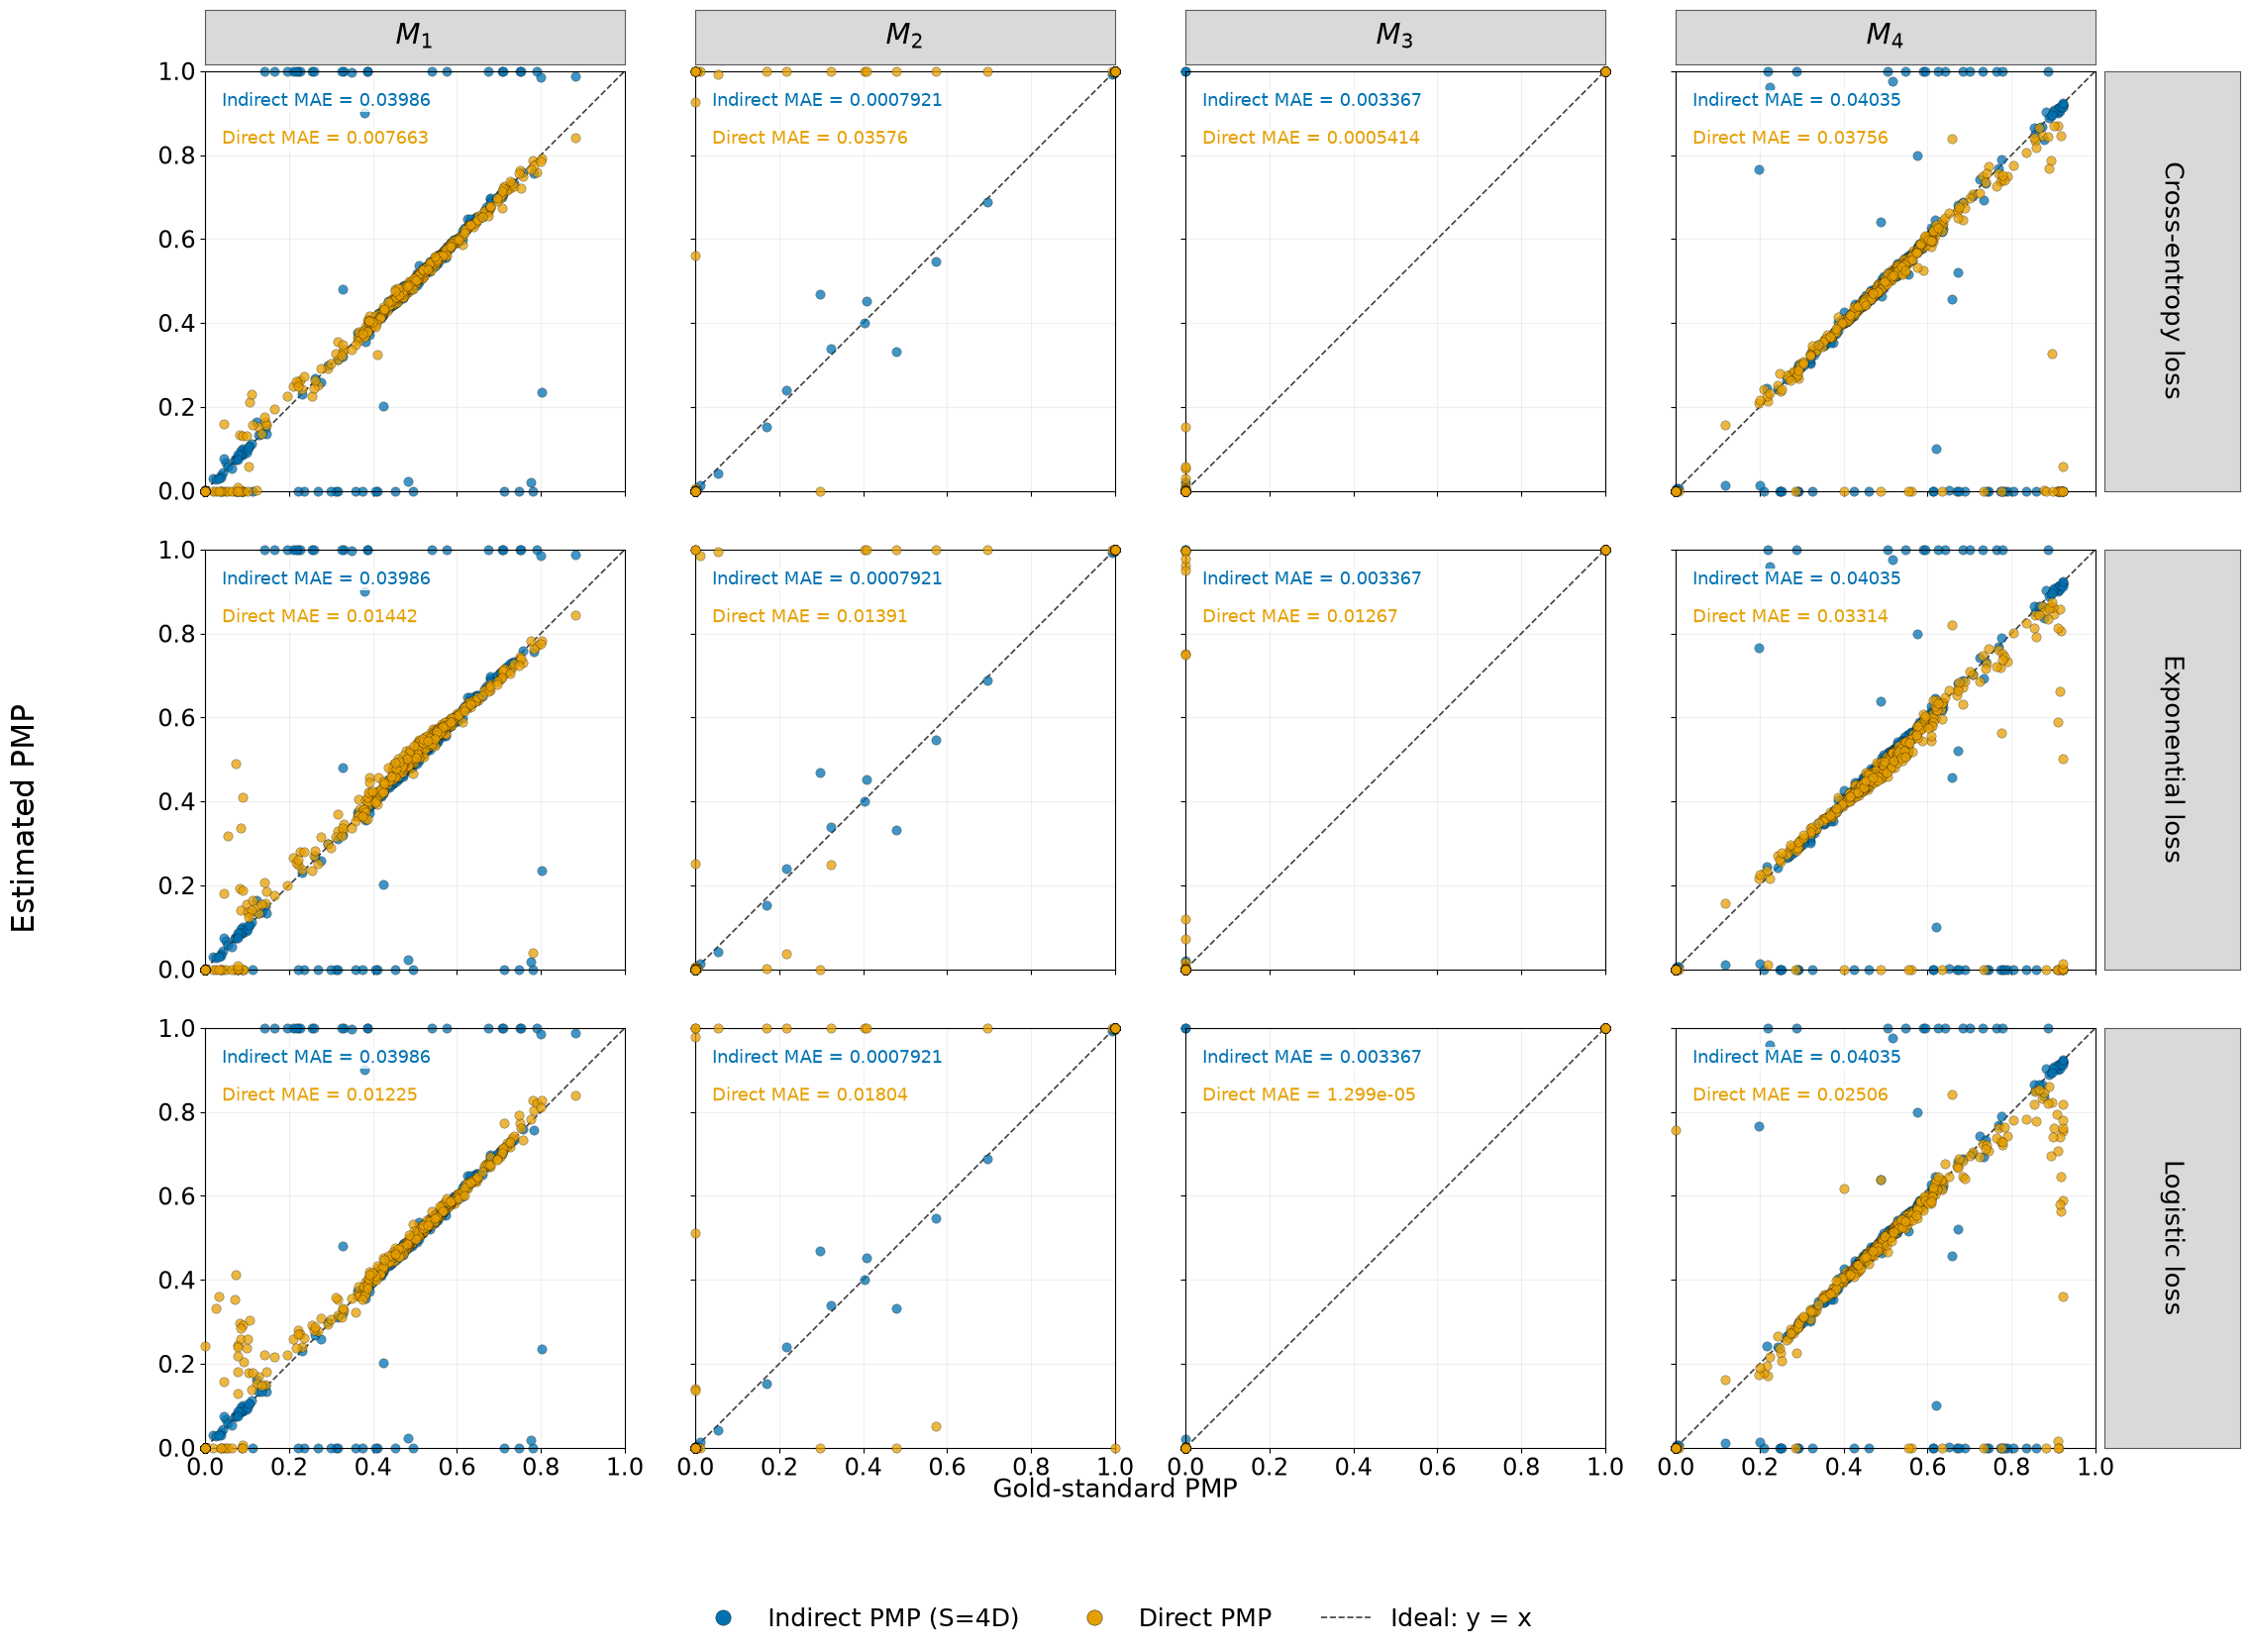

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/figures/pmp_recovery_all_losses_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/figures/pmp_recovery_all_losses_all.pdf


In [11]:
method_colors = {"indirect": "#0072B2", "direct": "#E69F00"}

with plt.rc_context({"font.size": 17, "savefig.facecolor": "white"}):
    figure_height = 17.5
    fig, axes = plt.subplots(3, 4, figsize=(23.5, figure_height),
                             sharex=True, sharey=True)
    fig.subplots_adjust(left=0.105, right=0.925, bottom=2.4 / figure_height,
                        top=1.0 - 1.2 / figure_height, wspace=0.12, hspace=0.14)

    for loss, row_axes in zip(LOSS_FUNCTIONS, axes, strict=True):
        data = plot_data_by_loss[loss]
        for model, ax in zip(MODELS, row_axes, strict=True):
            gold = data[f"p_gold_{model}"].to_numpy(float)
            indirect = data[f"p_indirect_{model}"].to_numpy(float)
            direct = data[f"p_direct_{model}"].to_numpy(float)

            ax.set_axisbelow(True)
            ax.grid(alpha=0.2)
            ax.plot([0, 1], [0, 1], "--", color="0.25", linewidth=1.2, zorder=1)
            for method, estimate in (("indirect", indirect), ("direct", direct)):
                ax.scatter(gold, estimate, s=45, marker="o",
                           color=method_colors[method], alpha=0.75,
                           edgecolors="black", linewidths=0.25,
                           zorder=2 if method == "indirect" else 3,
                           clip_on=False)
            for y, method, estimate in ((0.95, "indirect", indirect),
                                        (0.86, "direct", direct)):
                mae = np.mean(np.abs(estimate - gold))
                ax.text(0.04, y, f"{method.capitalize()} MAE = {mae:.4g}",
                        transform=ax.transAxes, ha="left", va="top",
                        color=method_colors[method], fontsize=13,
                        bbox={"facecolor": "white", "edgecolor": "none",
                              "alpha": 0.8, "pad": 1.4}, zorder=4)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_aspect("equal", adjustable="box")
            ax.tick_params(labelbottom=loss == LOSS_FUNCTIONS[-1],
                           labelleft=model == MODELS[0], labelsize=17)

    add_recovery_facet_strips(
        fig, axes,
        [rf"$M_{{{model[1:]}}}$" for model in MODELS],
        [f"{LOSS_LABELS[loss]} loss" for loss in LOSS_FUNCTIONS],
    )
    fig.supxlabel("Gold-standard PMP", y=0.105, fontsize=19)
    fig.supylabel("Estimated PMP", x=0.025, fontsize=22)
    legend_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=11,
               markerfacecolor=method_colors[method], markeredgecolor="black",
               markeredgewidth=0.3, label=label)
        for method, label in (("indirect", "Indirect PMP (S=4D)"),
                              ("direct", "Direct PMP"))
    ]
    legend_handles.append(
        Line2D([], [], linestyle="--", color="0.25", linewidth=1.2,
               label="Ideal: y = x")
    )
    fig.legend(handles=legend_handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.3125 / figure_height), ncol=3,
               frameon=False, fontsize=18, columnspacing=2.0)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    png_path = FIGURE_DIR / f"pmp_recovery_all_losses_{figure_suffix}.png"
    pdf_path = FIGURE_DIR / f"pmp_recovery_all_losses_{figure_suffix}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")


## Recovery by source model


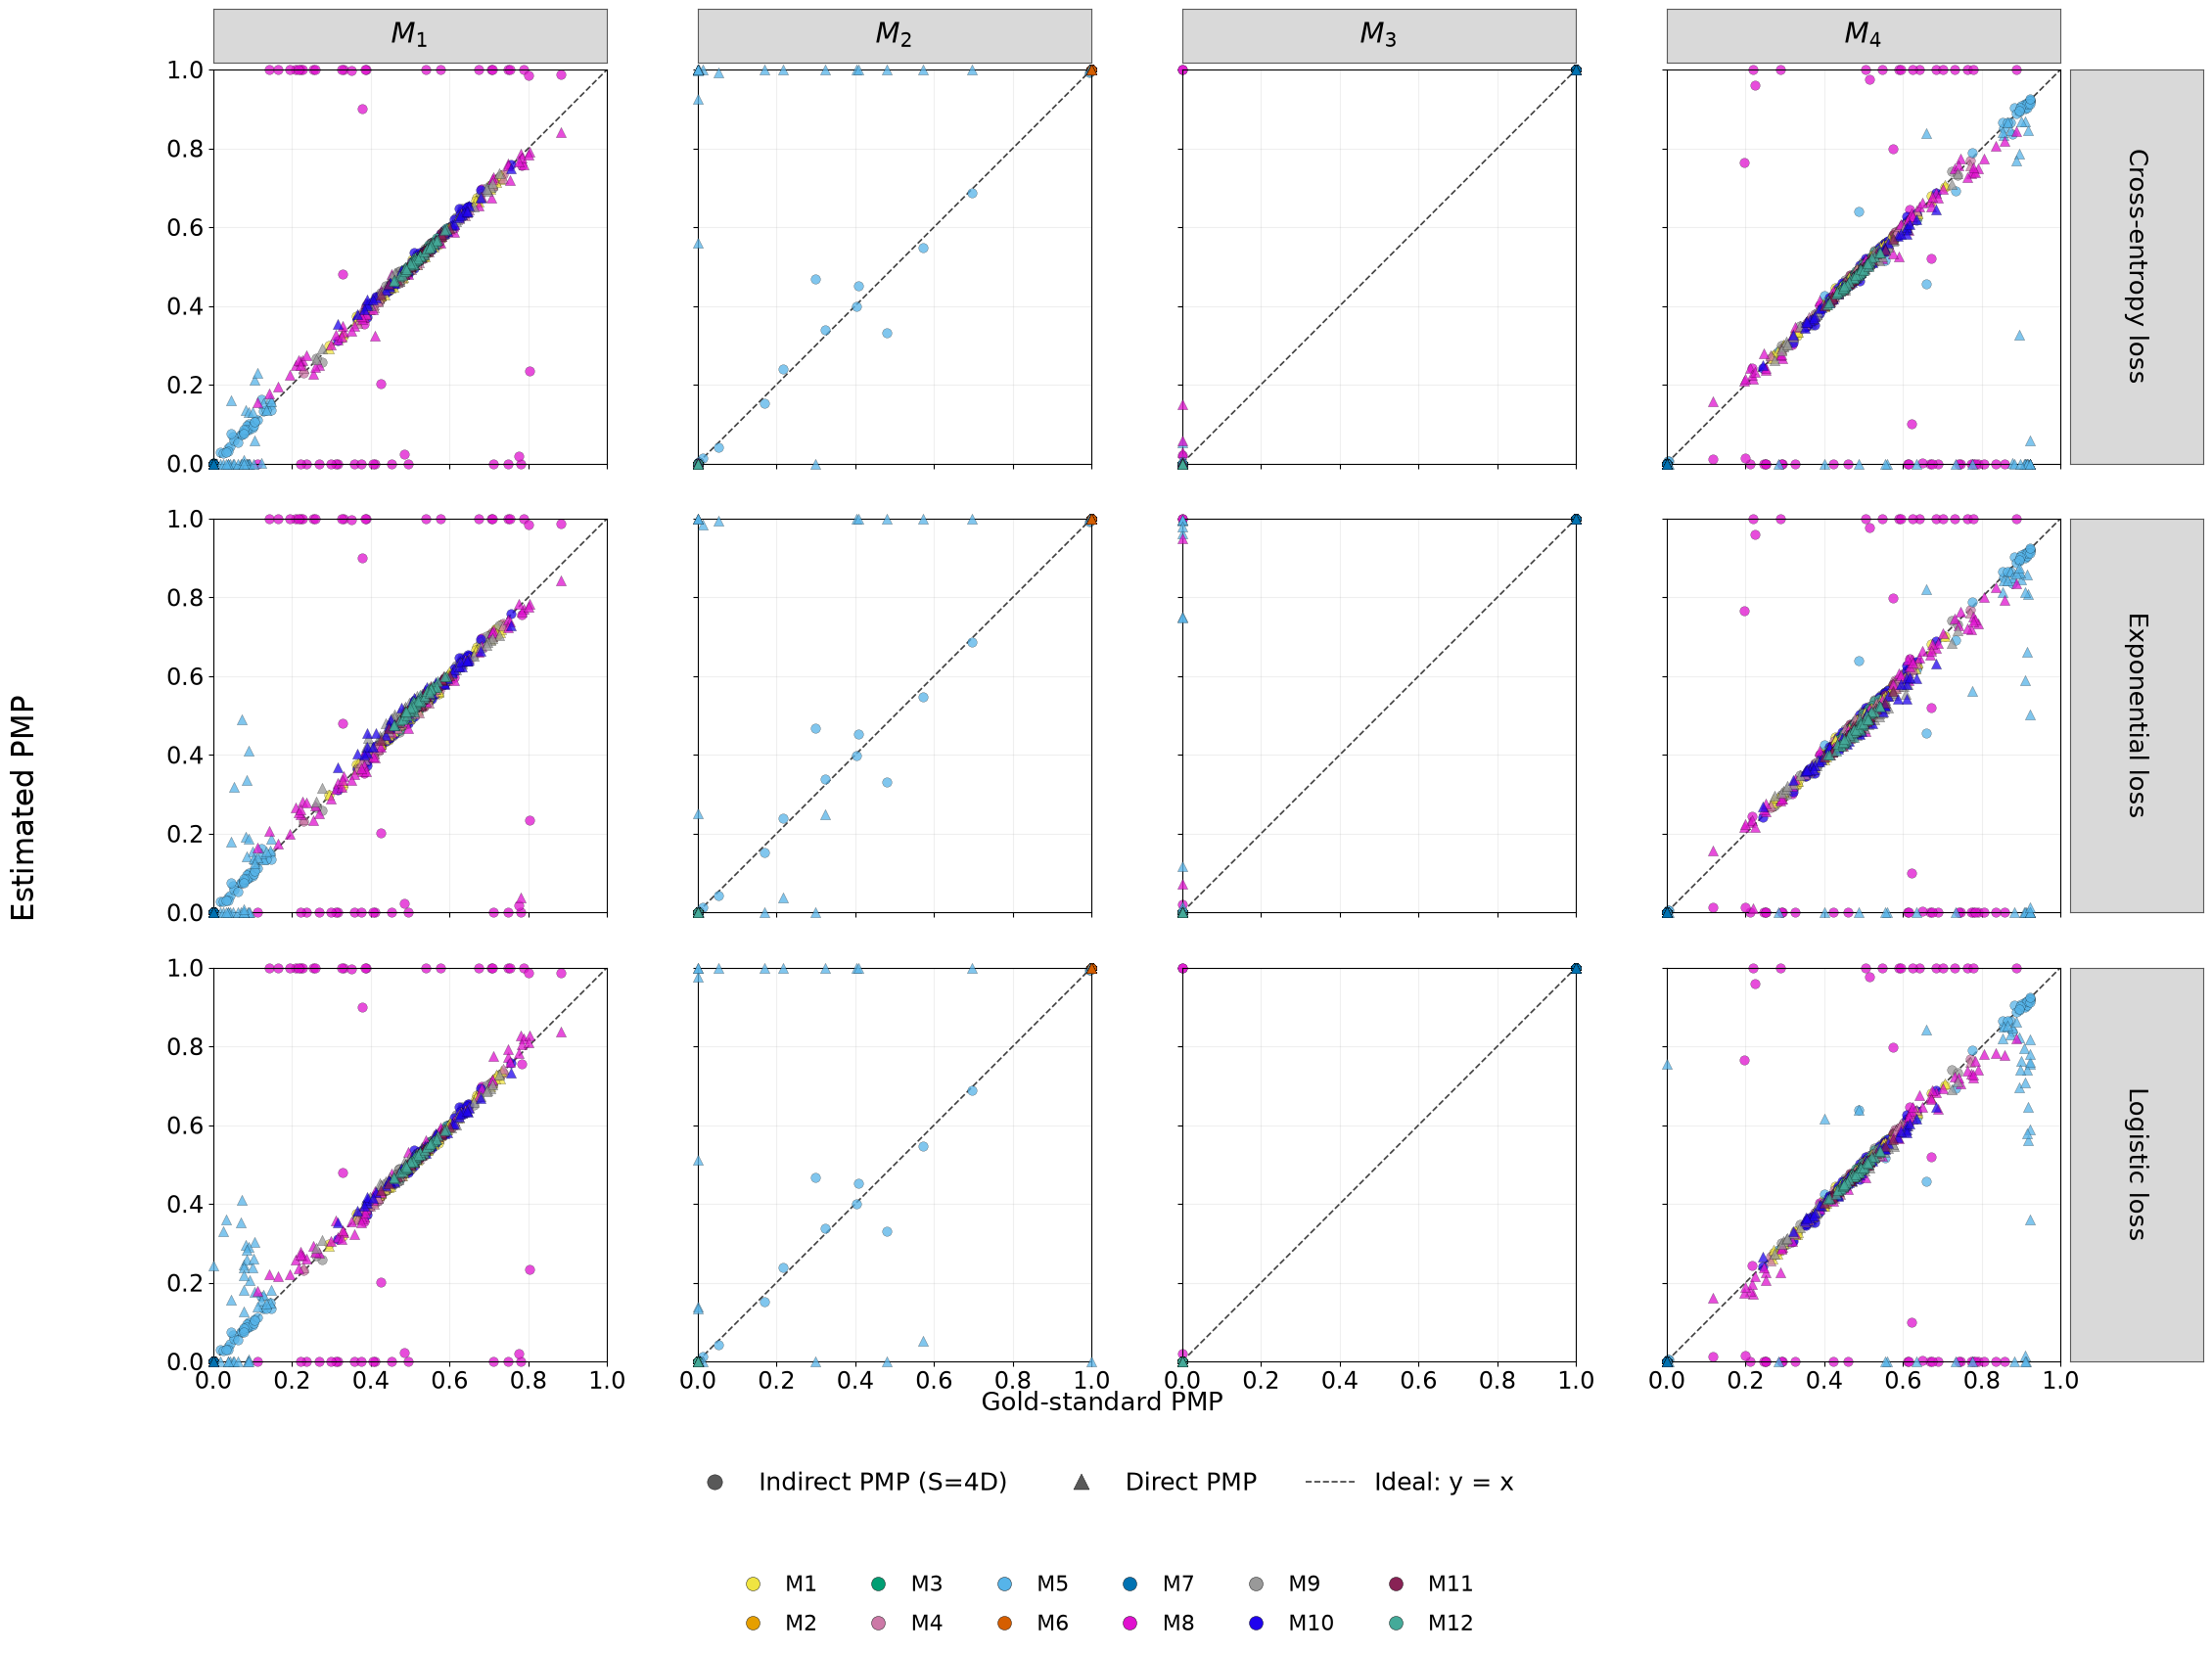

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/figures/pmp_recovery_by_source_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/figures/pmp_recovery_by_source_all.pdf


In [12]:
example_data = plot_data_by_loss[LOSS_FUNCTIONS[0]]
source_models = sorted(
    example_data.index.get_level_values("source_model").unique(),
    key=lambda source: int(str(source).lower().removeprefix("m")),
)
method_markers = {"indirect": "o", "direct": "^"}
SOURCE_COLORS = (
    "#F0E442", "#E69F00", "#009E73", "#CC79A7",
    "#56B4E9", "#D55E00", "#0072B2", "#E011CF",
    "#999999", "#1F03EE", "#882255", "#44AA99",
)
if len(source_models) > len(SOURCE_COLORS):
    raise ValueError(f"{len(source_models)} source models but only {len(SOURCE_COLORS)} source colors.")
source_colors = dict(zip(source_models, SOURCE_COLORS, strict=False))

with plt.rc_context({"font.size": 17, "savefig.facecolor": "white"}):
    figure_height = 17.5
    fig, axes = plt.subplots(3, 4, figsize=(23.5, figure_height),
                             sharex=True, sharey=True)
    fig.subplots_adjust(left=0.105, right=0.925, bottom=3.1 / figure_height,
                        top=1.0 - 1.2 / figure_height, wspace=0.12, hspace=0.14)

    for loss, row_axes in zip(LOSS_FUNCTIONS, axes, strict=True):
        plot_data = plot_data_by_loss[loss]
        for model, ax in zip(MODELS, row_axes, strict=True):
            ax.set_axisbelow(True)
            ax.grid(alpha=0.2)
            ax.plot([0, 1], [0, 1], "--", color="0.25", linewidth=1.2, zorder=1)
            for source in source_models:
                sub = plot_data.xs(source, level="source_model", drop_level=False)
                gold = sub[f"p_gold_{model}"].to_numpy(float)
                for method, estimate in (
                    ("indirect", sub[f"p_indirect_{model}"].to_numpy(float)),
                    ("direct", sub[f"p_direct_{model}"].to_numpy(float)),
                ):
                    ax.scatter(gold, estimate, s=48 if method == "indirect" else 55,
                               marker=method_markers[method], color=source_colors[source],
                               alpha=0.75, edgecolors="black", linewidths=0.2,
                               zorder=2 if method == "indirect" else 3, clip_on=False)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
            ax.set_yticks(np.linspace(0, 1, 6))
            ax.set_aspect("equal", adjustable="box")
            ax.tick_params(labelbottom=loss == LOSS_FUNCTIONS[-1],
                           labelleft=model == MODELS[0], labelsize=17)

    add_recovery_facet_strips(
        fig, axes,
        [rf"$M_{{{model[1:]}}}$" for model in MODELS],
        [f"{LOSS_LABELS[loss]} loss" for loss in LOSS_FUNCTIONS],
    )
    fig.supxlabel("Gold-standard PMP", y=0.145, fontsize=19)
    fig.supylabel("Estimated PMP", x=0.025, fontsize=22)
    method_handles = [
        Line2D([], [], linestyle="none", marker=method_markers[method],
               markersize=11, markerfacecolor="0.35", markeredgecolor="black",
               markeredgewidth=0.3, label=label)
        for method, label in (("indirect", "Indirect PMP (S=4D)"),
                              ("direct", "Direct PMP"))
    ]
    method_handles.append(Line2D([], [], linestyle="--", color="0.25",
                                 linewidth=1.2, label="Ideal: y = x"))
    source_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=10,
               markerfacecolor=source_colors[source], markeredgecolor="black",
               markeredgewidth=0.3, label=str(source).upper())
        for source in source_models
    ]
    fig.legend(handles=method_handles, loc="lower center",
               bbox_to_anchor=(0.5, 1.5 / figure_height), ncol=3,
               frameon=False, fontsize=18, columnspacing=2.0)
    fig.legend(handles=source_handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.1 / figure_height),
               ncol=min(6, len(source_models)), frameon=False, fontsize=16,
               columnspacing=1.8, handletextpad=0.5, labelspacing=0.8)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    png_path = FIGURE_DIR / f"pmp_recovery_by_source_{figure_suffix}.png"
    pdf_path = FIGURE_DIR / f"pmp_recovery_by_source_{figure_suffix}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

print(f"PNG: {png_path}")
print(f"PDF: {pdf_path}")


## Signed direct PMP error versus diagnostic score


In [13]:
import importlib
from benchmark.examples import direct_detection

# Refresh local analysis code when this cell is rerun in an existing kernel.
importlib.reload(direct_detection)
evaluate_direct_detection = direct_detection.evaluate_direct_detection
plot_direct_scores = direct_detection.plot_direct_scores

DIAGNOSTICS = ("l2", "linf", "density", "mmd")
LOSS_COLORS = {"cross_entropy": "#0072B2", "exponential": "#E69F00", "logistic": "#CC79A7"}
diagnostic_data_by_loss = {}
detection_metrics = []
for loss in LOSS_FUNCTIONS:
    directory = RESULTS_DIR / f"direct_{loss}"
    calibration_path = directory / "calibration" / "thresholds.csv"
    calibration_metadata = json.loads((directory / "calibration" / "metadata.json").read_text())
    if calibration_metadata["output_sha256"]["thresholds"] != file_sha256(calibration_path):
        raise ValueError(f"Stale PMP calibration dataset for {loss}")
    diagnostic_data_by_loss[loss], metrics = evaluate_direct_detection(
        diagnostic_frames_by_loss[loss],
        comparison_by_loss[loss],
        pd.read_csv(calibration_path),
        keys=("source_model", "id"),
        loss=loss,
    )
    detection_metrics.append(metrics)
detection_metrics = pd.concat(detection_metrics, ignore_index=True)
metrics_path = RESULTS_DIR / "direct_loss_comparison" / "diagnostic_detection_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
detection_metrics.to_csv(metrics_path, index=False)
display(detection_metrics)

,loss_function,diagnostic,n_datasets,n_high_error,pmp_error_coverage,pmp_error_lower_threshold_m1,pmp_error_upper_threshold_m1,pmp_error_lower_threshold_m2,pmp_error_upper_threshold_m2,pmp_error_lower_threshold_m3,...,pmp_error_lower_threshold_m4,pmp_error_upper_threshold_m4,diagnostic_rho_threshold,TP,FP,TN,FN,FNR,FPR,ROC_AUC
0,cross_entropy,l2,600,220,0.9,-0.009042,0.003127,0.0,1.016704e-06,0.0,...,-0.003128,0.009039,1.0,15,58,322,205,0.931818,0.152632,0.393840
1,cross_entropy,linf,600,220,0.9,-0.009042,0.003127,0.0,1.016704e-06,0.0,...,-0.003128,0.009039,1.0,19,56,324,201,0.913636,0.147368,0.412727
2,cross_entropy,density,600,220,0.9,-0.009042,0.003127,0.0,1.016704e-06,0.0,...,-0.003128,0.009039,1.0,72,106,274,148,0.672727,0.278947,0.569007
3,cross_entropy,mmd,600,220,0.9,-0.009042,0.003127,0.0,1.016704e-06,0.0,...,-0.003128,0.009039,1.0,10,112,268,210,0.954545,0.294737,0.341758
4,exponential,l2,600,268,0.9,-0.008574,0.011434,0.0,4.743081e-13,0.0,...,-0.011434,0.008574,1.0,51,91,241,217,0.809701,0.274096,0.460709
5,exponential,linf,600,268,0.9,-0.008574,0.011434,0.0,4.743081e-13,0.0,...,-0.011434,0.008574,1.0,44,58,274,224,0.835821,0.174699,0.442074
6,exponential,density,600,268,0.9,-0.008574,0.011434,0.0,4.743081e-13,0.0,...,-0.011434,0.008574,1.0,121,120,212,147,0.548507,0.361446,0.567468
7,exponential,mmd,600,268,0.9,-0.008574,0.011434,0.0,4.743081e-13,0.0,...,-0.011434,0.008574,1.0,0,61,271,268,1.000000,0.183735,0.257418
8,logistic,l2,600,190,0.9,-0.006530,0.006654,0.0,8.389951e-07,0.0,...,-0.006654,0.006528,1.0,16,60,350,174,0.915789,0.146341,0.549884
9,logistic,linf,600,190,0.9,-0.006530,0.006654,0.0,8.389951e-07,0.0,...,-0.006654,0.006528,1.0,14,55,355,176,0.926316,0.134146,0.521155


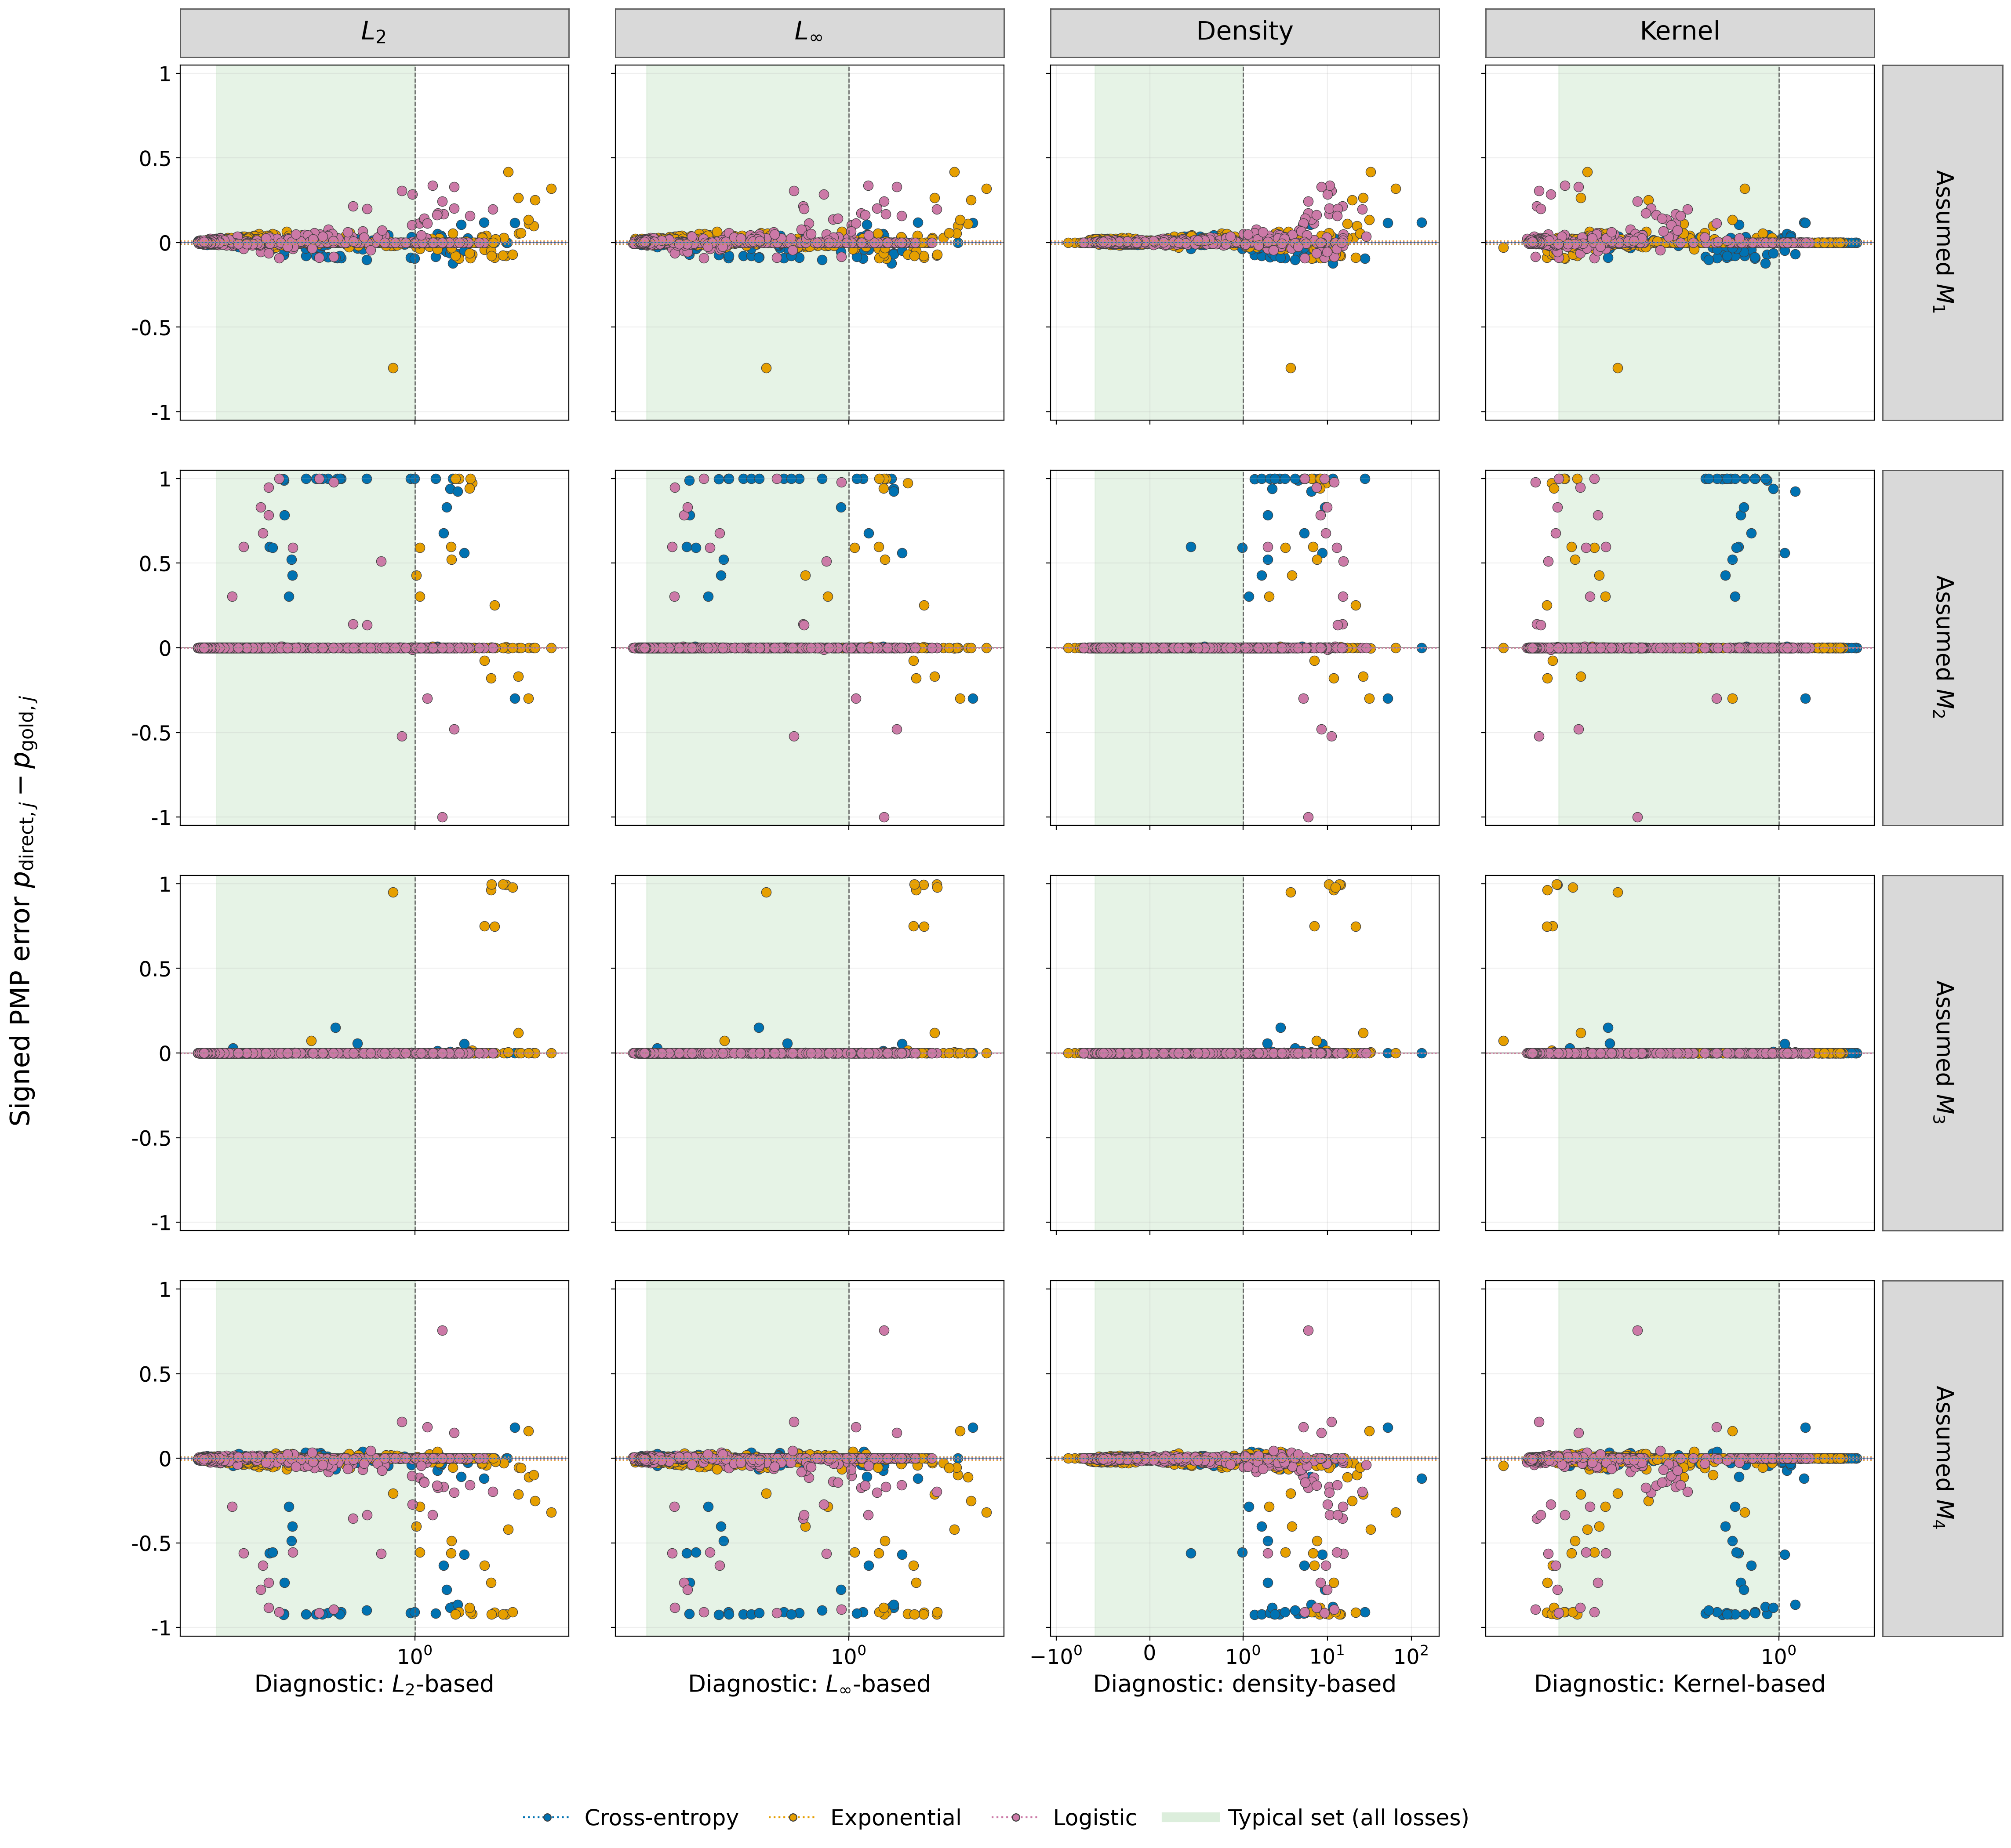

Saved diagnostic detection metrics to /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/diagnostic_detection_metrics.csv


In [14]:
from IPython.display import Image, display

selected_by_loss = {
    loss: data.loc[data["source_model"].isin(SOURCES_TO_PLOT)]
    for loss, data in diagnostic_data_by_loss.items()
}
output_stem = FIGURE_DIR / f"direct_signed_pmp_error_all_losses_by_diagnostic_{figure_suffix}"
plot_direct_scores(
    selected_by_loss,
    loss_labels=LOSS_LABELS,
    loss_colors=LOSS_COLORS,
    output_stem=output_stem,
    facet_style=True,
    reference_style=True,
    point_size=64,
    point_alpha=1.0,
)
display(Image(filename=str(output_stem.with_suffix(".png"))))
print(f"Saved diagnostic detection metrics to {metrics_path}")

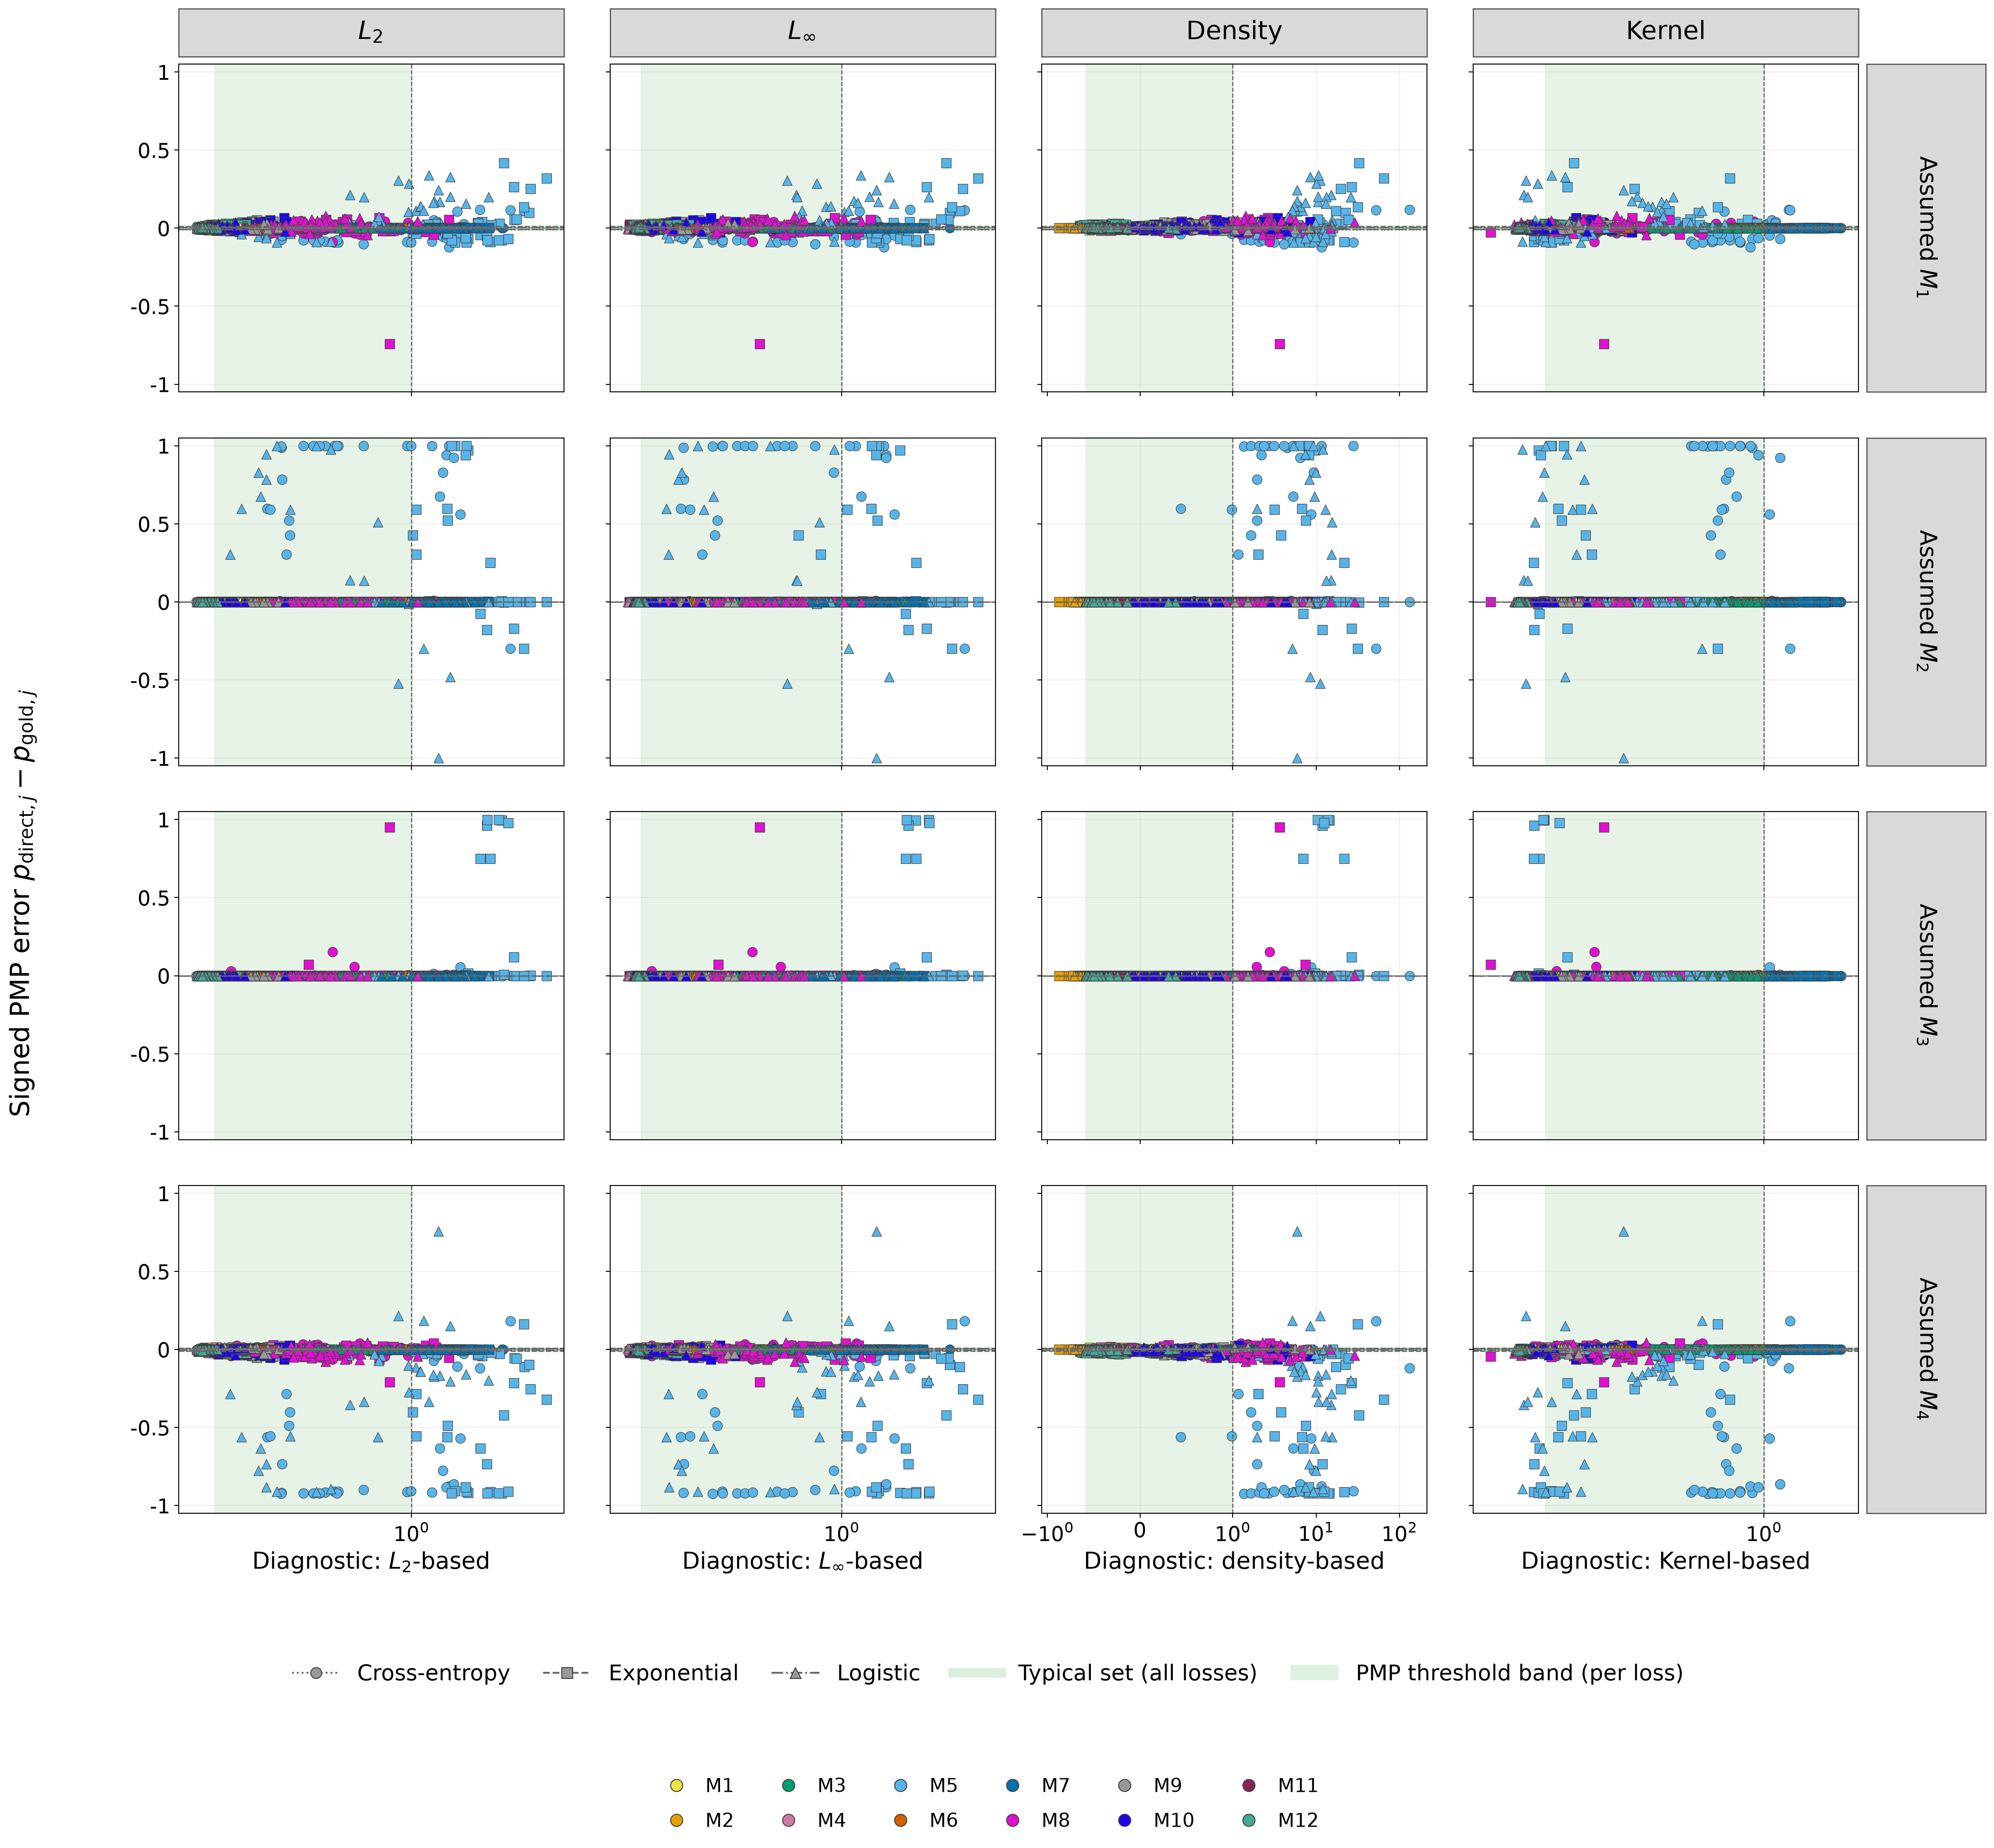

PNG: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/figures/direct_signed_pmp_error_by_source_and_loss_all.png
PDF: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/direct/direct_loss_comparison/figures/direct_signed_pmp_error_by_source_and_loss_all.pdf


In [15]:
# Marker shape identifies the direct loss; point color identifies the source model.
LAST_PLOT_Y_SCALE = "linear"  # Switch to "linear" for the original y axis.
LAST_PLOT_Y_SYMLOG_LINTHRESH = 0.01  # Linear region: -0.01 to 0.01.
LAST_PLOT_Y_LIMITS = (-1.05, 1.05)
LOSS_MARKERS = {"cross_entropy": "o", "exponential": "s", "logistic": "^"}
selected_sources = sorted(
    {source for data in selected_by_loss.values() for source in data["source_model"].unique()},
    key=lambda source: int(str(source).lower().removeprefix("m")),
)
source_colors_for_plot = {source: source_colors[source] for source in selected_sources}
source_output_stem = FIGURE_DIR / f"direct_signed_pmp_error_by_source_and_loss_{figure_suffix}"
plot_direct_scores(
    selected_by_loss,
    loss_labels=LOSS_LABELS,
    loss_colors=LOSS_COLORS,
    output_stem=source_output_stem,
    facet_style=True,
    reference_style=True,
    point_size=64,
    point_alpha=1.0,
    source_colors=source_colors_for_plot,
    loss_markers=LOSS_MARKERS,
    y_scale=LAST_PLOT_Y_SCALE,
    y_symlog_linthresh=LAST_PLOT_Y_SYMLOG_LINTHRESH,
    y_limits=LAST_PLOT_Y_LIMITS,
    pmp_threshold_band=True,
)
display(Image(filename=str(source_output_stem.with_suffix(".png"))))
print(f"PNG: {source_output_stem.with_suffix('.png')}")
print(f"PDF: {source_output_stem.with_suffix('.pdf')}")
